# Exploratory Data Analysis (EDA)

There are four data sources in `.csv` format (see README for more details):
- MIT-BIH Supraventricular Arrhythmia Database
- MIT-BIH Arrhythmia Database
- St. Petersburg INCART 12-lead Arrhythmia Database
- Sudden Cardiac Death Holter Database

This is a supervised machine learning project using a neural classifier model. Our `target` has the following classes:
- N = Normal
- SVEB = SupraVentricular Ectopic Beat
- VEB = Ventricular Ectopic Beat
- F = Fusion beat 
- Q = Unclassifiable

SVEB, VEB, F, and Q are considered "abnormal" classes, where N is considered as "normal". The goal of the model is therefore to predict a `target` class as either "abnormal" or "normal". A confidence score will also be given alongside the prediction. 

There are a total of 32 `features` (16 per lead).

## Goals of this notebook
> *note: these could be scoped in to other notebooks as needed*

### _raw data_
- shape?
- column names & dtypes?
- null values/empty strings?
- can I join all four datasets safely?
### _target variable_
- what is the class distribution of the 'type' column?
- is class imbalance 88/12 (normal/arrhythmia) as annotated? confirm this
- what is the class distribution after binary mapping? 
- do I drop Q? how much data would I lose? 
### _features_
- similar ranges?
- any low or near-zero-variance?
### _resampling_
- run SMOTE
- class distribution before resampling? after?
### _train/test split_
- are target class proportions preserved when we split the data?
### _data quality_
- any outliers in RR intervals or peak vals?
- anything else that might break pipeline? 

--- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load all data, adding a source column for eventual concatenation
incart = pd.read_csv('../data/incart-2lead-arrhythmia.csv', dtype={'type': str}).assign(source='incart')
mb_arr = pd.read_csv('../data/mit-bih-arrhythmia.csv', dtype={'type': str}).assign(source='mb_arr')
mb_supra = pd.read_csv('../data/mit-bih-supraventricular.csv', dtype={'type': str}).assign(source='mb_supra')
holter = pd.read_csv('../data/sudden-cardiac-death-holter.csv', dtype={'type': str}).assign(source='holter')

In [3]:
holter.dtypes

record            float64
type                  str
0_pre-RR          float64
0_post-RR         float64
0_pPeak           float64
0_tPeak           float64
0_rPeak           float64
0_sPeak           float64
0_qPeak           float64
0_qrs_interval    float64
0_pq_interval     float64
0_qt_interval     float64
0_st_interval     float64
0_qrs_morph0      float64
0_qrs_morph1      float64
0_qrs_morph2      float64
0_qrs_morph3      float64
0_qrs_morph4      float64
1_pre-RR          float64
1_post-RR         float64
1_pPeak           float64
1_tPeak           float64
1_rPeak           float64
1_sPeak           float64
1_qPeak           float64
1_qrs_interval    float64
1_pq_interval     float64
1_qt_interval     float64
1_st_interval     float64
1_qrs_morph0      float64
1_qrs_morph1      float64
1_qrs_morph2      float64
1_qrs_morph3      float64
1_qrs_morph4      float64
source                str
dtype: object

In [4]:
# shapes
data = [incart, mb_arr, mb_supra, holter]
for df in data:
    print(df.shape)


(175729, 35)
(100689, 35)
(184428, 35)
(502808, 35)


In [5]:
# check if features are named the same
ref = set(incart.columns)
others = [mb_arr, mb_supra, holter]
for df in others:
    print(set(df.columns) == ref)

True
True
True


In [6]:
# null values
for df in data:
    print(df.isnull().sum())

record            0
type              0
0_pre-RR          0
0_post-RR         0
0_pPeak           0
0_tPeak           0
0_rPeak           0
0_sPeak           0
0_qPeak           0
0_qrs_interval    0
0_pq_interval     0
0_qt_interval     0
0_st_interval     0
0_qrs_morph0      0
0_qrs_morph1      0
0_qrs_morph2      0
0_qrs_morph3      0
0_qrs_morph4      0
1_pre-RR          0
1_post-RR         0
1_pPeak           0
1_tPeak           0
1_rPeak           0
1_sPeak           0
1_qPeak           0
1_qrs_interval    0
1_pq_interval     0
1_qt_interval     0
1_st_interval     0
1_qrs_morph0      0
1_qrs_morph1      0
1_qrs_morph2      0
1_qrs_morph3      0
1_qrs_morph4      0
source            0
dtype: int64
record            0
type              0
0_pre-RR          0
0_post-RR         0
0_pPeak           0
0_tPeak           0
0_rPeak           0
0_sPeak           0
0_qPeak           0
0_qrs_interval    0
0_pq_interval     0
0_qt_interval     0
0_st_interval     0
0_qrs_morph0      0
0_qrs_m

In [7]:
# check it is the holter one giving us nulls
holter['type'].isnull().sum()

np.int64(76217)

In [8]:
# check for empty strings
(holter == '').sum()

record            0
type              0
0_pre-RR          0
0_post-RR         0
0_pPeak           0
0_tPeak           0
0_rPeak           0
0_sPeak           0
0_qPeak           0
0_qrs_interval    0
0_pq_interval     0
0_qt_interval     0
0_st_interval     0
0_qrs_morph0      0
0_qrs_morph1      0
0_qrs_morph2      0
0_qrs_morph3      0
0_qrs_morph4      0
1_pre-RR          0
1_post-RR         0
1_pPeak           0
1_tPeak           0
1_rPeak           0
1_sPeak           0
1_qPeak           0
1_qrs_interval    0
1_pq_interval     0
1_qt_interval     0
1_st_interval     0
1_qrs_morph0      0
1_qrs_morph1      0
1_qrs_morph2      0
1_qrs_morph3      0
1_qrs_morph4      0
source            0
dtype: int64

In [9]:
holter[holter['type'].isnull()]


,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,source
80787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,10.0,24.0,9.0,-0.284738,-0.344359,-0.409605,-0.469067,-0.508570,holter
80788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,15.0,38.0,19.0,-0.258033,-0.258033,-0.321687,-0.382487,-0.431391,holter
80789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,10.0,30.0,16.0,-0.293037,-0.293037,-0.350551,-0.402216,-0.441403,holter
80790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,8.0,30.0,17.0,-0.182425,-0.236507,-0.294031,-0.349195,-0.394899,holter
80791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,14.0,30.0,11.0,-0.208960,-0.269114,-0.330791,-0.387531,-0.431471,holter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,38.0,66.0,28.0,-0.952204,-0.952204,-0.952204,-0.952204,-0.952204,holter
502804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,11.0,19.0,7.0,-0.436390,-0.436390,-0.436390,-0.436390,-0.436390,holter
502805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,26.0,16.0,-0.055057,-0.198951,-0.340800,-0.455721,-0.520716,holter
502806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,6.0,15.0,6.0,-1.190745,-1.190745,-1.154962,-1.154962,-1.016100,holter


In [10]:
holter[
    holter['record'].notnull() & holter['1_pre-RR'].isnull()
]

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,source
173987,35.0,N,224.0,190.0,0.031933,0.238903,0.715144,-0.628063,0.009161,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
173988,35.0,N,190.0,158.0,0.109921,-0.424611,0.741439,-0.672029,0.018613,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
173989,35.0,N,158.0,240.0,0.194884,-0.140052,1.064142,-0.829943,0.065708,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
173990,35.0,N,240.0,162.0,0.027954,0.686488,0.374520,0.374520,0.016743,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
173991,35.0,N,162.0,262.0,0.084676,0.818830,0.471187,0.471187,0.081704,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488891,51.0,N,234.0,232.0,-0.017432,1.217649,-0.238299,-0.238299,-0.337129,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
488892,51.0,N,232.0,240.0,-0.035288,1.284782,-0.215396,-0.215396,-0.334104,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
488893,51.0,N,240.0,254.0,-0.065522,1.266098,-0.187534,-0.187534,-0.278320,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter
488894,51.0,N,254.0,262.0,-0.051043,1.339300,-0.133335,-0.133335,-0.235646,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,holter


In [11]:
holter.tail(10000)

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,source
492808,52.0,N,154.0,152.0,-0.523508,0.444263,0.908519,-0.734156,-0.631929,18.0,...,2.0,9.0,19.0,8.0,-0.402681,-0.402681,-0.402681,-0.368458,-0.368458,holter
492809,52.0,N,152.0,158.0,-0.249876,0.187875,0.745106,-1.088510,-0.327464,17.0,...,2.0,10.0,18.0,6.0,-0.453260,-0.453260,-0.453260,-0.405937,-0.405937,holter
492810,52.0,N,158.0,152.0,0.033383,-0.585338,0.852773,-1.021635,-0.234966,16.0,...,4.0,9.0,26.0,13.0,-0.517775,-0.517775,-0.509432,-0.461106,-0.384413,holter
492811,52.0,N,152.0,156.0,-0.028148,0.234453,1.230683,-0.799259,-0.288160,22.0,...,0.0,16.0,36.0,20.0,-0.583507,-0.583507,-0.583507,-0.583507,-0.583507,holter
492812,52.0,N,156.0,156.0,0.111803,-0.084418,1.626827,-0.433396,0.088315,15.0,...,2.0,8.0,18.0,8.0,-0.378827,-0.378827,-0.378827,-0.348287,-0.348287,holter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,38.0,66.0,28.0,-0.952204,-0.952204,-0.952204,-0.952204,-0.952204,holter
502804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,11.0,19.0,7.0,-0.436390,-0.436390,-0.436390,-0.436390,-0.436390,holter
502805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,26.0,16.0,-0.055057,-0.198951,-0.340800,-0.455721,-0.520716,holter
502806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,6.0,15.0,6.0,-1.190745,-1.190745,-1.154962,-1.154962,-1.016100,holter


In [12]:
null_positions = holter[holter['record'].isnull()].index
null_positions


Index([ 80787,  80788,  80789,  80790,  80791,  80792,  80793,  80794,  80795,
        80796,
       ...
       502798, 502799, 502800, 502801, 502802, 502803, 502804, 502805, 502806,
       502807],
      dtype='int64', length=76217)

In [13]:
null_positions.max() - null_positions.min() + 1 == len(null_positions)

np.False_

In [14]:
np.diff(null_positions)

array([1, 1, 1, ..., 1, 1, 1], shape=(76216,))

In [15]:
(np.diff(null_positions) != 1).sum()

np.int64(2)

In [16]:
null_positions.min()

np.int64(80787)

In [17]:
null_positions.max()

np.int64(502807)

In [18]:
len(holter)

502808

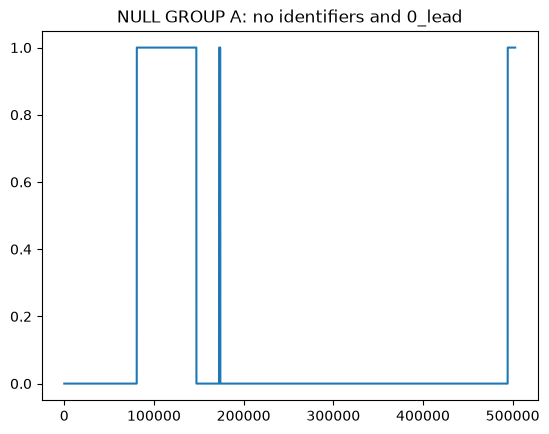

In [ ]:
# visualise nulls by index: value of 1 is a null row
# call this group A: where the identifiers and 0-lead are missing
plt.plot(holter['record'].isnull())
plt.title('NULL GROUP A: no identifiers and 0_lead')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

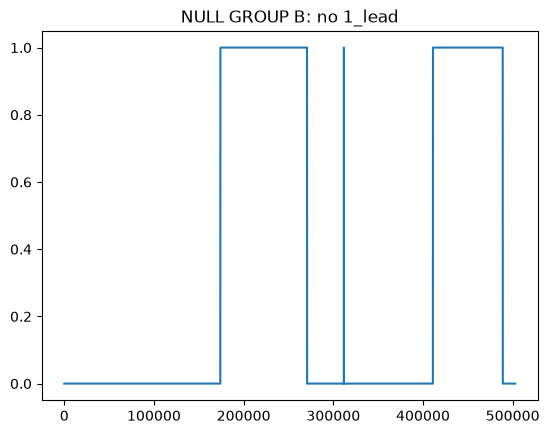

In [ ]:
# repeat for the other case, group B
# less severe, as identifiers ('record', 'type') are intact
plt.plot(
    holter['record'].notnull() & holter['1_pre-RR'].isnull()
)
plt.title('NULL GROUP B: no 1_lead')
plt.show

In [21]:
len(incart) + len(mb_arr) + len(mb_supra)

460846

In [ ]:
# drop all rows with null values (groups A & B)
holter = holter.dropna()

In [23]:
len(holter)

251976

In [24]:
holter.info()

<class 'pandas.DataFrame'>
Index: 251976 entries, 0 to 494413
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          251976 non-null  float64
 1   type            251976 non-null  str    
 2   0_pre-RR        251976 non-null  float64
 3   0_post-RR       251976 non-null  float64
 4   0_pPeak         251976 non-null  float64
 5   0_tPeak         251976 non-null  float64
 6   0_rPeak         251976 non-null  float64
 7   0_sPeak         251976 non-null  float64
 8   0_qPeak         251976 non-null  float64
 9   0_qrs_interval  251976 non-null  float64
 10  0_pq_interval   251976 non-null  float64
 11  0_qt_interval   251976 non-null  float64
 12  0_st_interval   251976 non-null  float64
 13  0_qrs_morph0    251976 non-null  float64
 14  0_qrs_morph1    251976 non-null  float64
 15  0_qrs_morph2    251976 non-null  float64
 16  0_qrs_morph3    251976 non-null  float64
 17  0_qrs_morph4    251976 non

In [25]:
for df in [holter, mb_arr, mb_supra]:
    df['record'] = df['record'].astype(str)

In [26]:
for df in data:
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].astype('float64')

In [27]:
dtype_compare = pd.DataFrame({
    'incart': incart.dtypes,
    'mb_arr': mb_arr.dtypes,
    'mb_supra': mb_supra.dtypes,
    'holter': holter.dtypes
})

dtype_compare

,incart,mb_arr,mb_supra,holter
record,str,str,str,str
type,str,str,str,str
0_pre-RR,float64,float64,float64,float64
0_post-RR,float64,float64,float64,float64
0_pPeak,float64,float64,float64,float64
0_tPeak,float64,float64,float64,float64
0_rPeak,float64,float64,float64,float64
0_sPeak,float64,float64,float64,float64
0_qPeak,float64,float64,float64,float64
0_qrs_interval,float64,float64,float64,float64


In [28]:
all_data = pd.concat([incart, mb_arr, mb_supra, holter], ignore_index=True)
all_data

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,source
0,I01,N,163.0,165.0,0.069610,-0.083281,0.614133,-0.392761,0.047159,15.0,...,14.0,3.0,23.0,6.0,-0.023370,-0.011650,0.082608,0.101373,-0.183387,incart
1,I01,N,165.0,166.0,-0.097030,0.597254,-0.078704,-0.078704,-0.137781,3.0,...,15.0,5.0,27.0,7.0,0.081637,0.102992,0.191225,0.217544,-0.068248,incart
2,I01,N,166.0,102.0,0.109399,0.680528,-0.010649,-0.010649,-0.720620,6.0,...,33.0,13.0,52.0,6.0,-0.148539,-0.060620,0.081080,0.204400,0.335172,incart
3,I01,VEB,102.0,231.0,0.176376,0.256431,-0.101098,-0.707525,-0.101098,4.0,...,21.0,9.0,34.0,4.0,0.046898,0.083728,0.279512,0.526785,0.450969,incart
4,I01,N,231.0,165.0,0.585577,0.607461,-0.083499,-0.083499,-0.167858,3.0,...,32.0,5.0,43.0,6.0,-0.112552,0.012989,0.091491,0.134004,0.265232,incart
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712817,52.0,N,76.0,148.0,-0.345439,1.086720,-0.213846,-0.213846,-0.699650,24.0,...,1.0,8.0,29.0,20.0,-0.443458,-0.443458,-0.443458,-0.443458,-0.443458,holter
712818,52.0,N,148.0,104.0,0.095040,0.804837,0.211167,0.211167,0.008211,4.0,...,50.0,9.0,67.0,8.0,-0.224660,-0.120400,-0.016600,0.028074,0.123550,holter
712819,52.0,N,32.0,22.0,1.603278,-0.518048,-0.531231,-0.531231,-1.296207,16.0,...,8.0,6.0,39.0,25.0,0.521029,0.490847,0.369275,0.281510,0.121812,holter
712820,52.0,N,56.0,82.0,-0.942216,-1.074539,-0.955163,-1.249941,-0.955163,7.0,...,73.0,6.0,115.0,36.0,0.940757,1.275964,0.376596,-0.212226,-0.621249,holter


In [34]:
len(incart) + len(mb_arr) + len(mb_supra) + len(holter)

712822

In [35]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 712822 entries, 0 to 712821
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          712822 non-null  str    
 1   type            712822 non-null  str    
 2   0_pre-RR        712822 non-null  float64
 3   0_post-RR       712822 non-null  float64
 4   0_pPeak         712822 non-null  float64
 5   0_tPeak         712822 non-null  float64
 6   0_rPeak         712822 non-null  float64
 7   0_sPeak         712822 non-null  float64
 8   0_qPeak         712822 non-null  float64
 9   0_qrs_interval  712822 non-null  float64
 10  0_pq_interval   712822 non-null  float64
 11  0_qt_interval   712822 non-null  float64
 12  0_st_interval   712822 non-null  float64
 13  0_qrs_morph0    712822 non-null  float64
 14  0_qrs_morph1    712822 non-null  float64
 15  0_qrs_morph2    712822 non-null  float64
 16  0_qrs_morph3    712822 non-null  float64
 17  0_qrs_morph4    71282

In [ ]:
all_data['record'].nunique()

208

In [ ]:
# check to see if number of unique records == the composite key we will use for train/test split
all_data[['source','record']].drop_duplicates().shape[0] == all_data['record'].nunique()

True

In [44]:
all_data['type'].value_counts(normalize=True)

type
N       0.904449
VEB     0.067635
SVEB    0.025955
F       0.001761
Q       0.000201
Name: proportion, dtype: float64